In [1]:
import torch
from kan import KAN as PyKAN
from kan.utils import create_dataset, add_symbolic, ex_round
from matplotlib import pyplot as plt
from torch import nn, optim
from tqdm import tqdm

from efficient_kan.kan import KAN as EffKAN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 特殊函数实验（正弦积分）

本实验关注正弦积分函数：

$$Si(x) = \int_0^x rac{\sin(t)}{t} dt$$

该函数不能由常见初等函数的有限复合表示，因此属于特殊函数。和多数符号回归算法相比，PyKAN 仍可给出有效近似，不过精度受网络深度影响较大。
考虑到可解释性，这里采用相对小型的网络结构。

## 数据集与可视化

In [2]:
steps = 1000
sine_integral = lambda x: torch.stack(
    [-torch.trapz(
        torch.sin(torch.linspace(0.000001, xi.item(), steps=steps)) /
        torch.linspace(0.000001, xi.item(), steps=steps), dx=xi.item() / steps
    ) for xi in x]
)

dataset = create_dataset(sine_integral, n_var=1, ranges=[-20, 20], train_num=5000, normalize_label=True,
                         normalize_input=True)

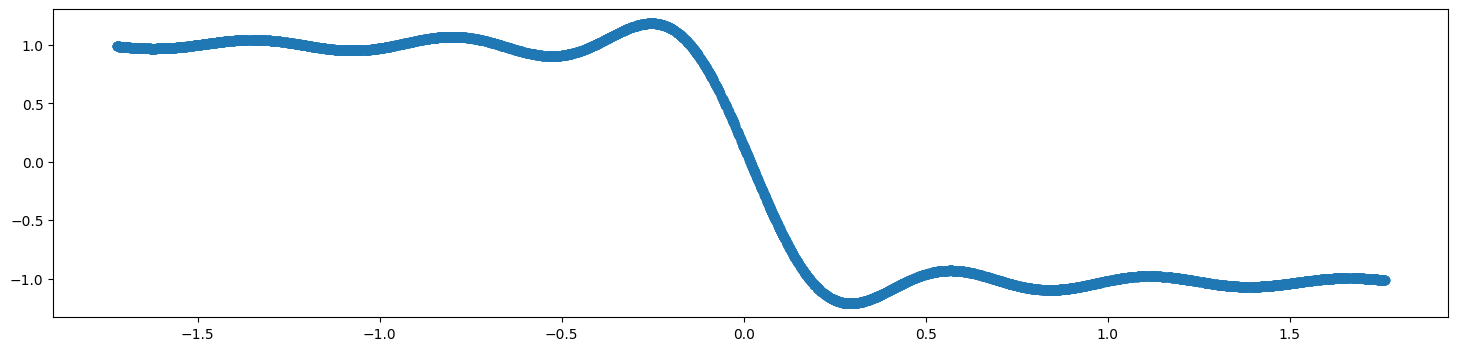

In [3]:
fig, ax = plt.subplots()
ax.scatter(dataset["train_input"].to('cpu'), dataset["train_label"].to('cpu'))
fig.set_size_inches(18, 4)
plt.show()

## PyKAN 训练

In [4]:
model = PyKAN(width=[1, 2, 1, 1], grid=5, k=3)
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, lamb_entropy=4)
pass

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.69e-02 | test_loss: 3.56e-02 | reg: 1.15e+01 | : 100%|█| 50/50 [00:24<00:00,  2.01it


saving model version 0.1


### PyKAN 学到了什么？
向模型输入等间距采样点，观察其对目标函数的近似形态。

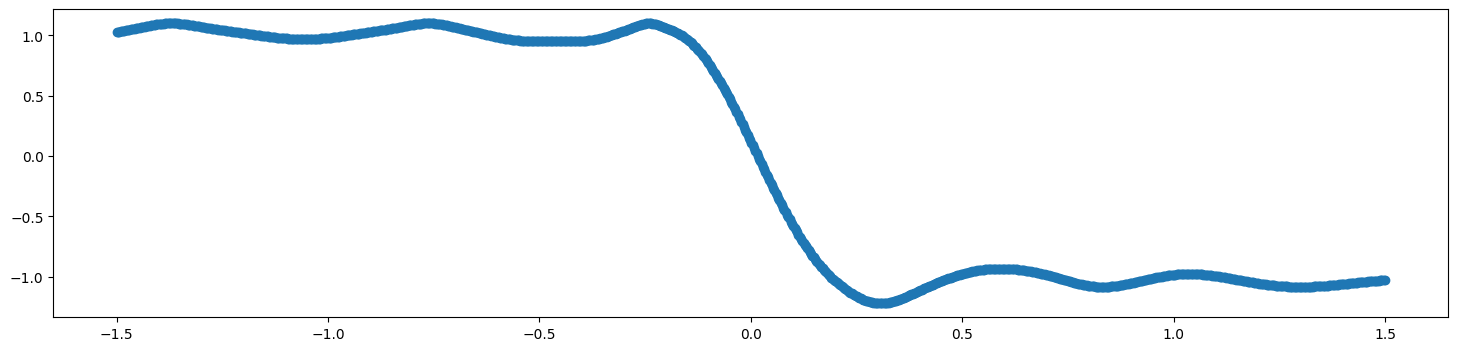

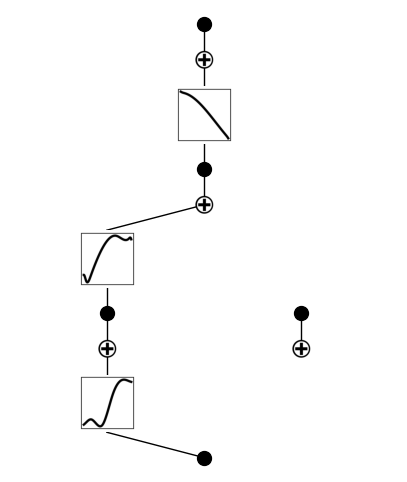

In [5]:
x_axis_kan = torch.linspace(-1.5, 1.5, steps=steps)
y_axis_kan = model(x_axis_kan.view(-1, 1)).detach().numpy()
fig, ax = plt.subplots()
ax.scatter(x_axis_kan, y_axis_kan)
fig.set_size_inches(18, 4)
plt.show()
model.plot(scale=.5)

In [6]:
add_symbolic('sinx', lambda x:torch.sin(x).mul_(x))

In [7]:
model.suggest_symbolic(0,0,0)
model.suggest_symbolic(1,0,0)
model.suggest_symbolic(2,0,0)



  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0     sinx    0.977718 -5.487318           1                1   -0.297464
1        0    0.000000  0.000014           0                0    0.000003
2        x    0.837119 -2.618023           1                1    0.276395
3      sin    0.964807 -4.828169           2                2    0.634366
4      cos    0.964807 -4.828164           2                2    0.634367
  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0     sinx    0.971185 -5.116552           1                1   -0.223310
1        0    0.000000  0.000014           0                0    0.000003
2        x    0.891935 -3.209896           1                1    0.158021
3      sin    0.966095 -4.881934           2                2    0.623613
4      cos    0.966092 -4.881815           2                2    0.623637
  function  fitting r2    r2 loss  complexity  complexity loss  total loss
0     sinx    0.999964 -14.423001    

('sinx',
 (<function __main__.<lambda>(x)>, sinx, 1, <function __main__.<lambda>(x)>),
 0.9999644756317139,
 1)

r2 is 0.9777178168296814
saving model version 0.2
r2 is 0.9711853265762329
saving model version 0.3
r2 is 0.9999644756317139
saving model version 0.4


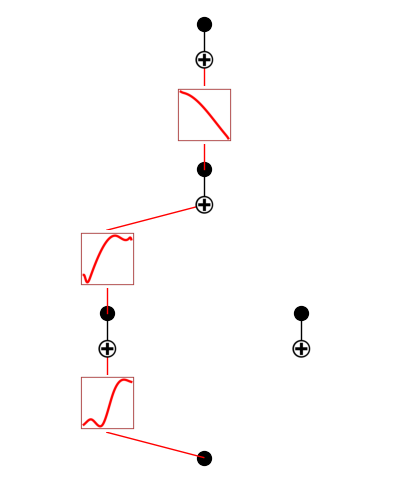

In [8]:
model.fix_symbolic(0, 0, 0, 'sinx')
model.fix_symbolic(1, 0, 0, 'sinx')
model.fix_symbolic(2, 0, 0, 'sinx')
model.plot()
pass

In [9]:
formula = model.symbolic_formula()[0][0]
ex_round(formula, 3)

0.457*sinx(1.017*sinx(0.398*sinx(-1.608*x_1 - 3.198) + 1.223) - 4.169) + 0.286

# EfficientKAN
进一步验证 EfficientKAN 在该任务上同样能达到较高精度。

In [10]:
class Efficient_KAN(nn.Module):
    def __init__(self, grid_size=200):
        super(Efficient_KAN, self).__init__()
        self.layers = [1, 1]
        self.model = EffKAN(self.layers,
                            grid_size=grid_size,
                            # grid_eps=1,
                            # scale_base=0,
                            # sp_trainable=False,
                            # sb_trainable=False,
                            # enable_standalone_scale_spline=False
                            ).to(device)
        self.double()

    def forward(self, x):
        # x = x / dataset_size * 2 - 1
        # x = x.view(-1, self.layers[0])
        x = self.model(x)
        return x

In [11]:
def train(model, optimizer, inputs: torch.Tensor, labels, epochs=5, batch_size=100):
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
    for epoch in range(epochs):
        model.train()
        with tqdm(range(inputs.size(0) // batch_size)) as pbar:
            for i in pbar:
                x = inputs[i * batch_size:(i + 1) * batch_size].to(device)
                y = labels[i * batch_size:(i + 1) * batch_size].to(device)
                optimizer.zero_grad()
                output = model(x)
                output = output.squeeze()
                loss = criterion(output, y.double())
                loss.backward()
                optimizer.step(closure=lambda: loss)
                pbar.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])
                scheduler.step()

In [12]:
model2 = Efficient_KAN(grid_size=5)
train(model2, optim.Adam(model2.parameters(), lr=0.025), dataset["train_input"], dataset["train_label"], epochs=20,
      batch_size=100)

  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\chenpeng\miniconda3\envs\kan\lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([100, 1])) that is different to the input size (torch.Size([100])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 50/50 [00:00<00:00, 448.65it/s, loss=0.992, lr=0.0092]


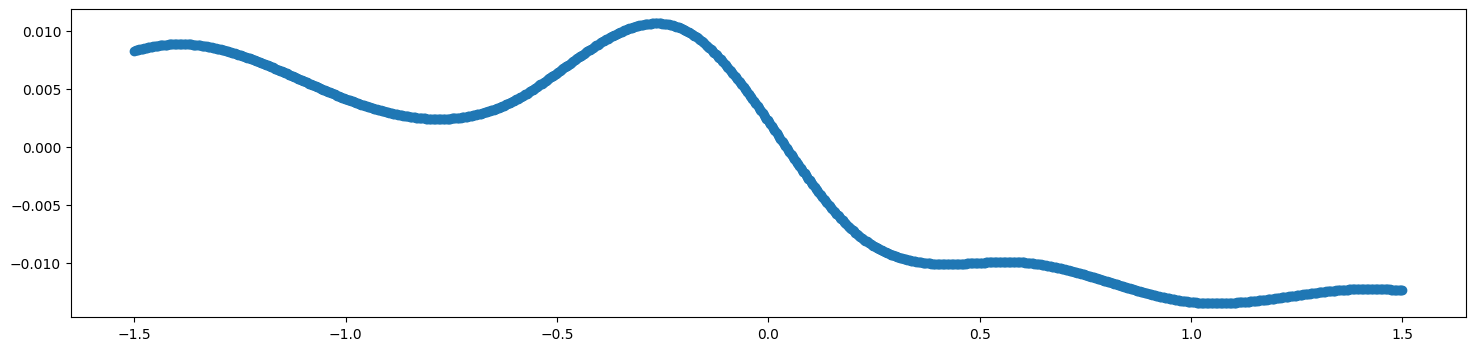

In [13]:
x_axis = torch.linspace(-1.5, 1.5, steps=steps)
y_axis = model2(x_axis.view(-1, 1)).detach().numpy()

fig, ax = plt.subplots()
ax.scatter(x_axis.cpu(), y_axis)  # x_axis移到CPU
fig.set_size_inches(18, 4)
plt.show()

## 更复杂的 KAN 结构

In [14]:
model3 = PyKAN(width=[1, 5, 2, 1], grid=4, k=3)
model3.fit(dataset, opt="LBFGS", steps=50, lr=1, lamb=0.00)
pass

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.30e-03 | test_loss: 2.32e-03 | reg: 1.86e+01 | : 100%|█| 50/50 [00:44<00:00,  1.11it

saving model version 0.1


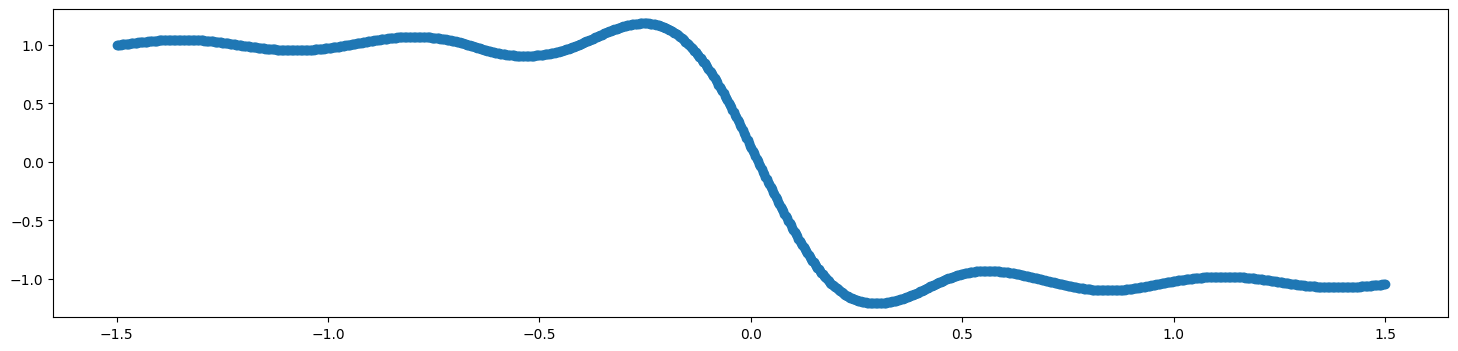

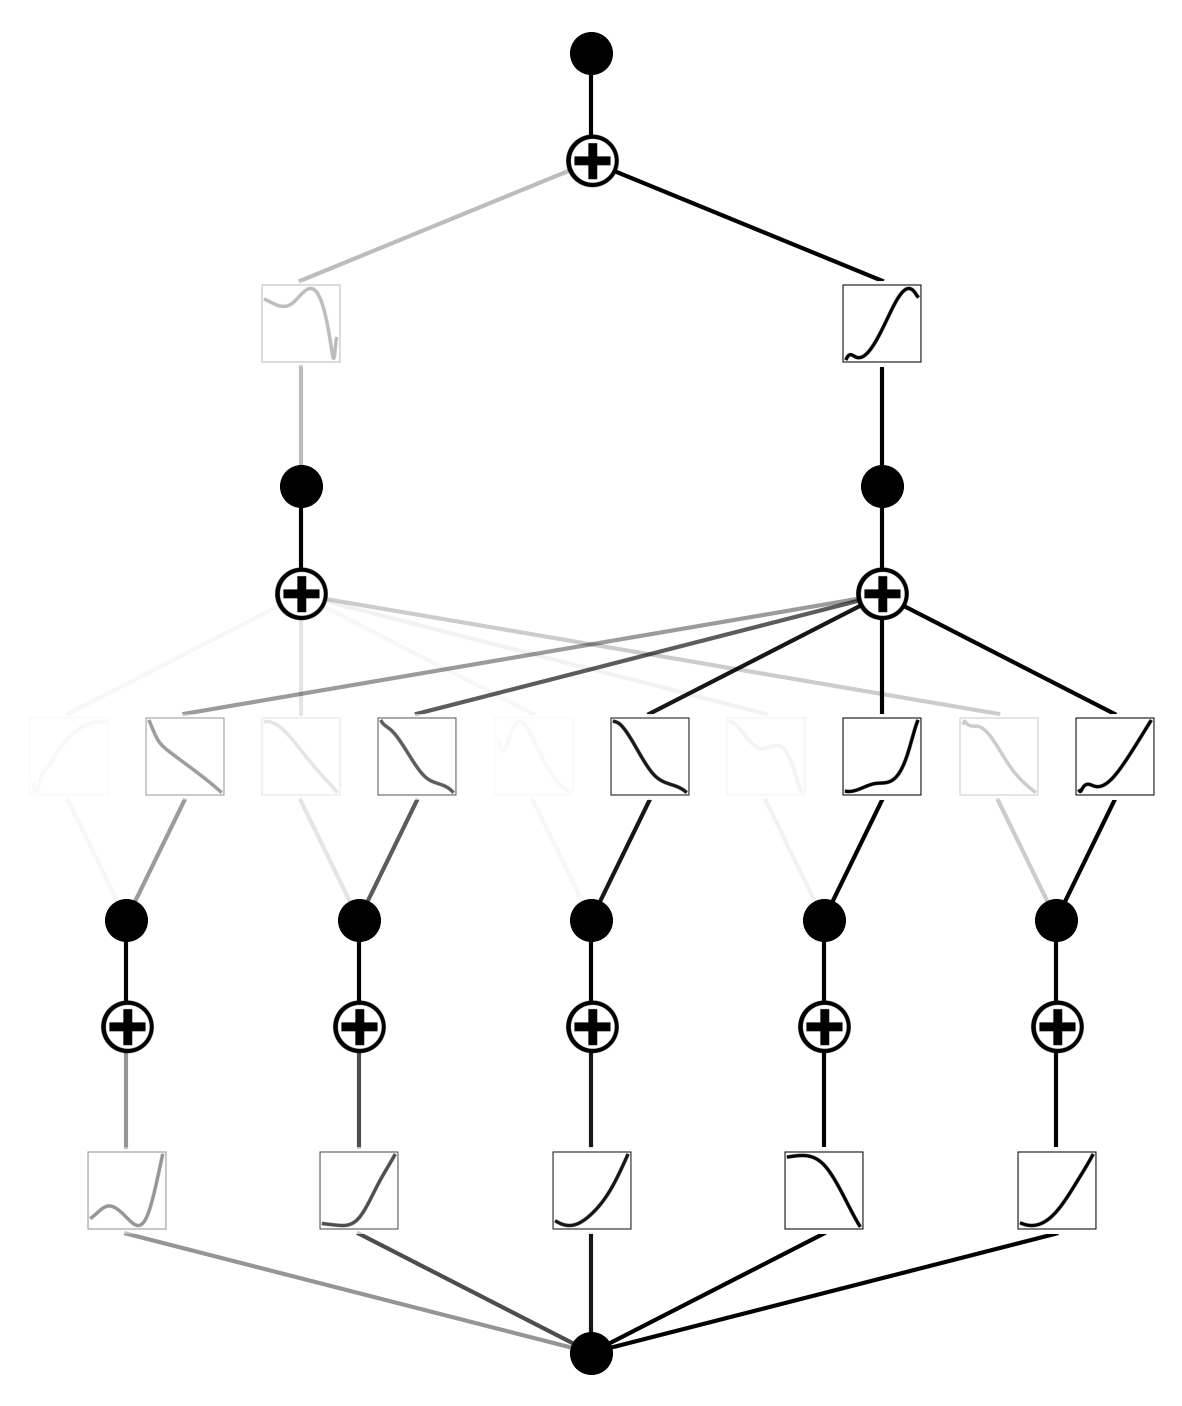

In [15]:
x_axis_com_kan = torch.linspace(-1.5, 1.5, steps=steps)
y_axis_com_kan = model3(x_axis_com_kan.view(-1, 1)).detach().numpy()
fig, ax = plt.subplots()
ax.scatter(x_axis_com_kan, y_axis_com_kan)
fig.set_size_inches(18, 4)
plt.show()

model3.plot(scale=1.5)

In [16]:
model3.auto_symbolic()

fixing (0,0,0) with sinx, r2=0.979206919670105, c=1
fixing (0,0,1) with sinx, r2=0.997767984867096, c=1
fixing (0,0,2) with sinx, r2=0.9998323321342468, c=1
fixing (0,0,3) with sinx, r2=0.9991671442985535, c=1
fixing (0,0,4) with sinx, r2=0.9999653100967407, c=1
fixing (1,0,0) with sinx, r2=0.9824525117874146, c=1
fixing (1,0,1) with sinx, r2=0.9778480529785156, c=1
fixing (1,1,0) with sinx, r2=0.999489426612854, c=1
fixing (1,1,1) with sinx, r2=0.9987038969993591, c=1
fixing (1,2,0) with 0, r2=0.0, c=0
fixing (1,2,1) with sinx, r2=0.9980573654174805, c=1
fixing (1,3,0) with sinx, r2=0.9467577934265137, c=1
fixing (1,3,1) with sinx, r2=0.9755755066871643, c=1
fixing (1,4,0) with sinx, r2=0.9976313710212708, c=1
fixing (1,4,1) with sinx, r2=0.9879087209701538, c=1
fixing (2,0,0) with 0, r2=0.0, c=0
fixing (2,1,0) with sinx, r2=0.9810184836387634, c=1
saving model version 0.2


In [17]:
formula3 = model3.symbolic_formula()[0][0]
ex_round(formula3, 3)

1.269 - 1.377*sinx(0.138*sinx(4.634 - 14.229*sinx(-0.188*x_1 - 0.185)) + 0.963*sinx(0.087*sinx(-1.821*x_1 - 1.313) + 2.383) + 0.066*sinx(0.514*sinx(-0.967*x_1 - 2.78) + 3.759) + 1.307*sinx(0.079*sinx(-0.779*x_1 - 8.804) - 2.613) + 5.984*sinx(-0.15*sinx(-0.751*x_1 - 2.692) - 2.193) - 11.977)

# 结果对比

本节对比三组结果：PyKAN、EfficientKAN 以及更复杂的 PyKAN。图中红线为真实函数，蓝线为模型学习结果。

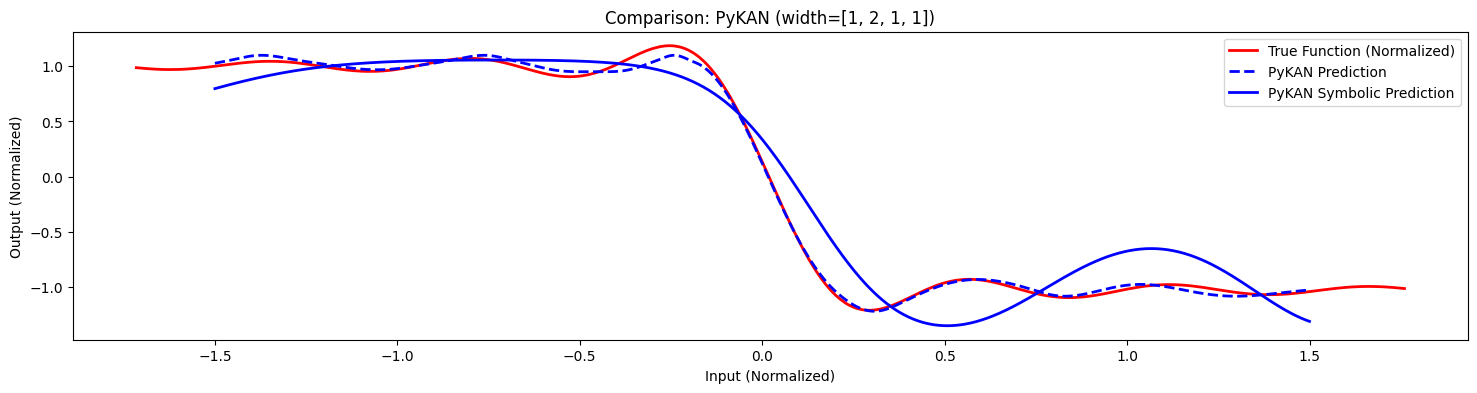

In [18]:
# 1. 基础 PyKAN 模型 (model) 结果对比

fig, ax = plt.subplots(figsize=(18, 4))

test_inputs = dataset['test_input']
test_labels = dataset['test_label']

with torch.no_grad():
    model_device = next(model3.parameters()).device
    model_dtype = next(model3.parameters()).dtype
    inputs_device = test_inputs.to(model_device).to(model_dtype)

# 排序 (红线真值，蓝线预测)
sort_idx = torch.argsort(test_inputs[:, 0])
x_axis_sorted = test_inputs[sort_idx, 0].numpy()
y_true_sorted = test_labels[sort_idx].numpy()

ax.plot(x_axis_sorted, y_true_sorted, 'r-', label='True Function (Normalized)', linewidth=2)

x_axis = torch.linspace(-1.5, 1.5, steps=steps)
y_axis = model(x_axis.view(-1, 1)).detach().numpy()


ax.plot(x_axis_kan, y_axis_kan, 'b--', label='PyKAN Prediction', linewidth=2)
ax.plot(x_axis, y_axis, 'b-', label='PyKAN Symbolic Prediction', linewidth=2)


ax.set_title("Comparison: PyKAN (width=[1, 2, 1, 1])")
ax.set_xlabel("Input (Normalized)")
ax.set_ylabel("Output (Normalized)")
ax.legend()
plt.show()

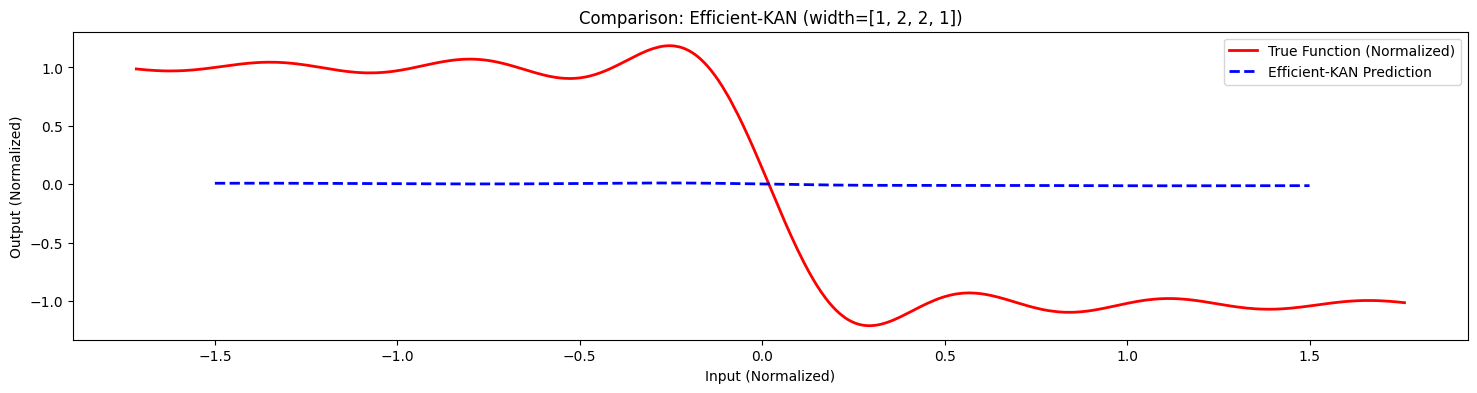

In [19]:
# 2. Efficient-KAN 模型 (model2) 结果对比
# model2 是 Efficient_KAN 实例，内部封装了 EffKAN 并使用了 double()
test_inputs = dataset['test_input']
test_labels = dataset['test_label']

with torch.no_grad():
    model_device = next(model3.parameters()).device
    model_dtype = next(model3.parameters()).dtype
    inputs_device = test_inputs.to(model_device).to(model_dtype)
    predictions = model3(inputs_device).cpu().detach().numpy()

# 排序 (红线真值，蓝线预测)
sort_idx = torch.argsort(test_inputs[:, 0])
x_axis_sorted = test_inputs[sort_idx, 0].numpy()
y_true_sorted = test_labels[sort_idx].numpy()
y_pred_sorted = predictions[sort_idx]


x_axis = torch.linspace(-1.5, 1.5, steps=steps).double().to(device)  # 确保在设备上

y_axis = model2(x_axis.view(-1, 1)).detach().cpu().numpy()  # 移到CPU


fig, ax = plt.subplots(figsize=(18, 4))


ax.plot(x_axis_sorted, y_true_sorted, 'r-', label='True Function (Normalized)', linewidth=2)
ax.plot(x_axis.cpu(), y_axis, 'b--', label='Efficient-KAN Prediction', linewidth=2)

ax.set_title("Comparison: Efficient-KAN (width=[1, 2, 2, 1])")
ax.set_xlabel("Input (Normalized)")
ax.set_ylabel("Output (Normalized)")
ax.legend()
plt.show()

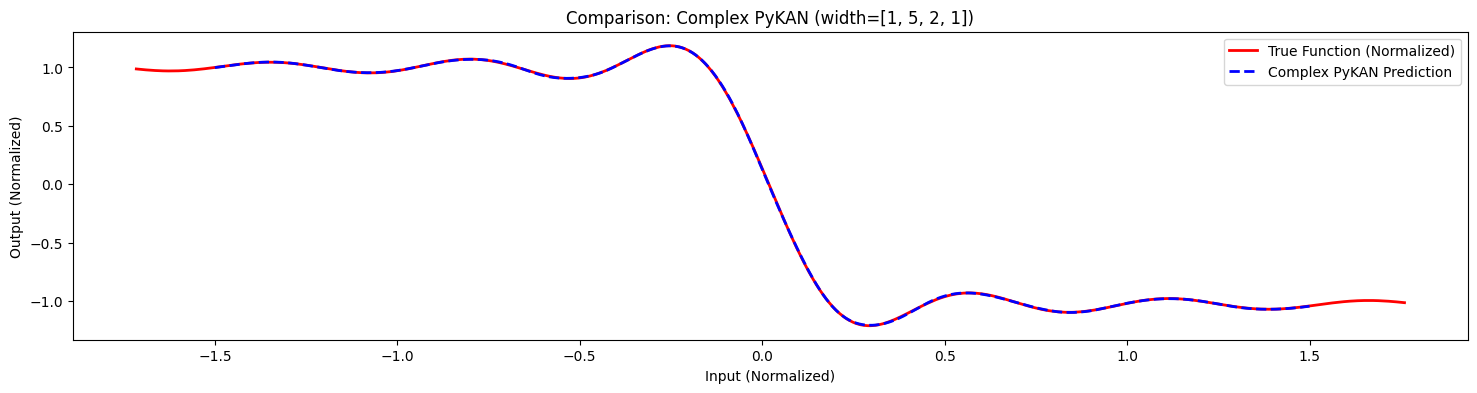

In [20]:
# 3. 复杂 PyKAN 模型 (model3) 结果对比
test_inputs = dataset['test_input']
test_labels = dataset['test_label']

with torch.no_grad():
    model_device = next(model3.parameters()).device
    model_dtype = next(model3.parameters()).dtype
    inputs_device = test_inputs.to(model_device).to(model_dtype)

# 排序 (红线真值，蓝线预测)
sort_idx = torch.argsort(test_inputs[:, 0])
x_axis_sorted = test_inputs[sort_idx, 0].numpy()
y_true_sorted = test_labels[sort_idx].numpy()

fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(x_axis_sorted, y_true_sorted, 'r-', label='True Function (Normalized)', linewidth=2)

ax.plot(x_axis_com_kan, y_axis_com_kan, 'b--', label='Complex PyKAN Prediction', linewidth=2)
ax.set_title("Comparison: Complex PyKAN (width=[1, 5, 2, 1])")
ax.set_xlabel("Input (Normalized)")
ax.set_ylabel("Output (Normalized)")
ax.legend()
plt.show()